# Crop Recommendation Data Preparation

This notebook audits the available crop datasets before model training.

The required model inputs are soil type, pH, nitrogen, phosphorus, potassium, soil moisture, temperature, and rainfall. The target is crop label.

Data safety rules used in this notebook:

- Raw files remain unchanged.
- Missing values are not imputed.
- Units are not converted unless the source unit is verified.
- Atmospheric humidity is not treated as soil moisture.
- Soil color is not treated as soil type.
- Precipitation near atmospheric pressure values is not treated as rainfall.
- Only approved crop spelling variants and established synonyms are mapped.
- Exact raw duplicates are removed only from cleaned copies and recorded in a manifest.
- No train validation test split is created in this phase.


## 1 Setup


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "processed_dataset").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "processed_dataset"
BY_SOURCE_DIR = PROCESSED_DIR / "by_source"
CLEANED_BY_SOURCE_DIR = PROCESSED_DIR / "cleaned_by_source"
METADATA_DIR = PROCESSED_DIR / "metadata"

REQUIRED_FEATURES = [
    "soil_type", "ph", "n", "p", "k",
    "soil_moisture", "temperature", "rainfall"
]

sns.set_theme(style="whitegrid", context="notebook")
CHART_COLOR = "#2f7d32"
PALETTE = "YlGn"


## 2 Dataset Inventory


In [2]:
inventory = pd.read_csv(METADATA_DIR / "dataset_inventory.csv")
inventory[
    [
        "source_file", "rows", "cleaned_rows", "columns_original", "crop_classes",
        "raw_duplicate_rows_after_first", "complete_required_rows",
        "quality_tier", "training_status"
    ]
].sort_values("rows", ascending=False)


,source_file,rows,cleaned_rows,columns_original,crop_classes,raw_duplicate_rows_after_first,complete_required_rows,quality_tier,training_status
3,crop yield prediction dataset.csv,246091,246091,15,120,0,0,quarantine,exclude_v1
6,crop_yield.csv,19689,19689,16,55,0,0,yield_reference,exclude_v1
4,crop-yield.csv,10000,10000,20,6,0,10000,complete_but_low_signal,exclude_until_signal_review
7,data_core.csv,8000,8000,9,11,0,0,reference_only,hold
8,original_dataset.csv,5000,1000,9,10,4000,0,quarantine,exclude_v1
1,Crop and fertilizer dataset.csv,4513,4513,11,16,0,0,reference_only,hold
0,Crop Recommendation using Soil Properties and Weather Prediction.csv,3867,3867,29,12,0,0,needs_semantic_verification,hold
2,Crop_Recommendation.csv,2200,2200,8,22,0,0,prototype_candidate,candidate_after_validation
5,crop_data.csv,694,646,7,91,48,0,reference_only,hold


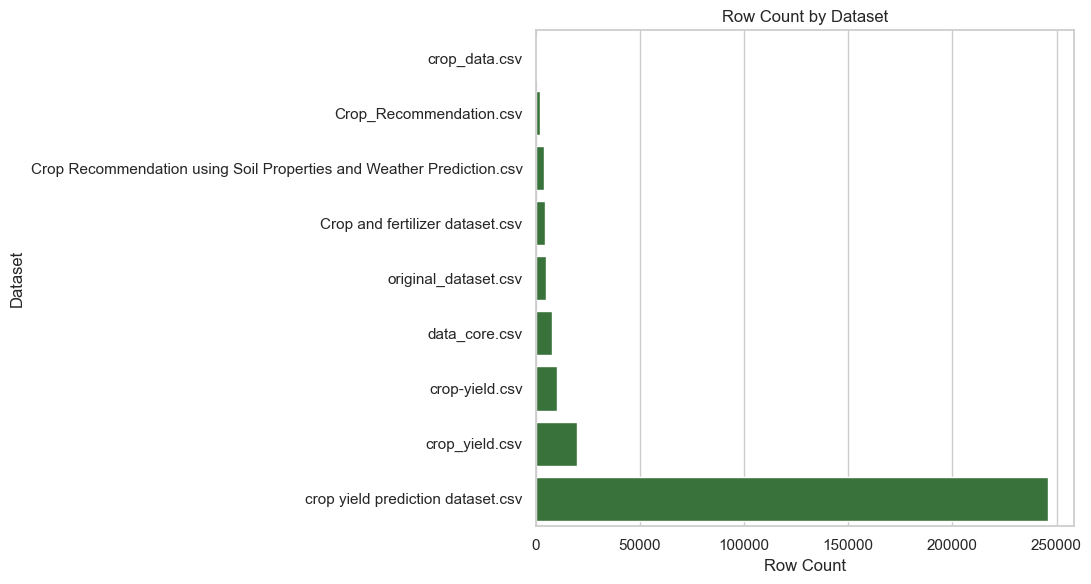

In [3]:
plot_data = inventory.sort_values("rows", ascending=True)
plt.figure(figsize=(11, 6))
sns.barplot(data=plot_data, x="rows", y="source_file", color=CHART_COLOR)
plt.title("Row Count by Dataset")
plt.xlabel("Row Count")
plt.ylabel("Dataset")
plt.tight_layout()
plt.show()


## 3 Required Feature Coverage


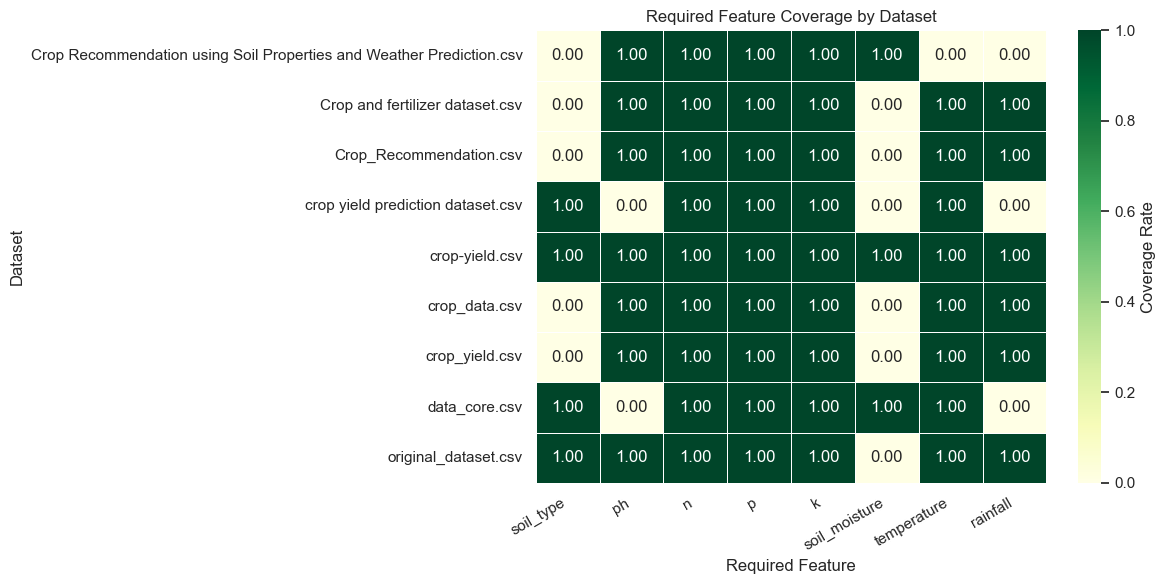

In [4]:
coverage = pd.read_csv(METADATA_DIR / "required_feature_coverage.csv")
coverage_matrix = coverage.pivot(
    index="source_file", columns="feature", values="coverage_rate"
).reindex(columns=REQUIRED_FEATURES)

plt.figure(figsize=(12, 6))
sns.heatmap(
    coverage_matrix,
    annot=True,
    fmt=".2f",
    cmap=PALETTE,
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Coverage Rate"},
)
plt.title("Required Feature Coverage by Dataset")
plt.xlabel("Required Feature")
plt.ylabel("Dataset")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


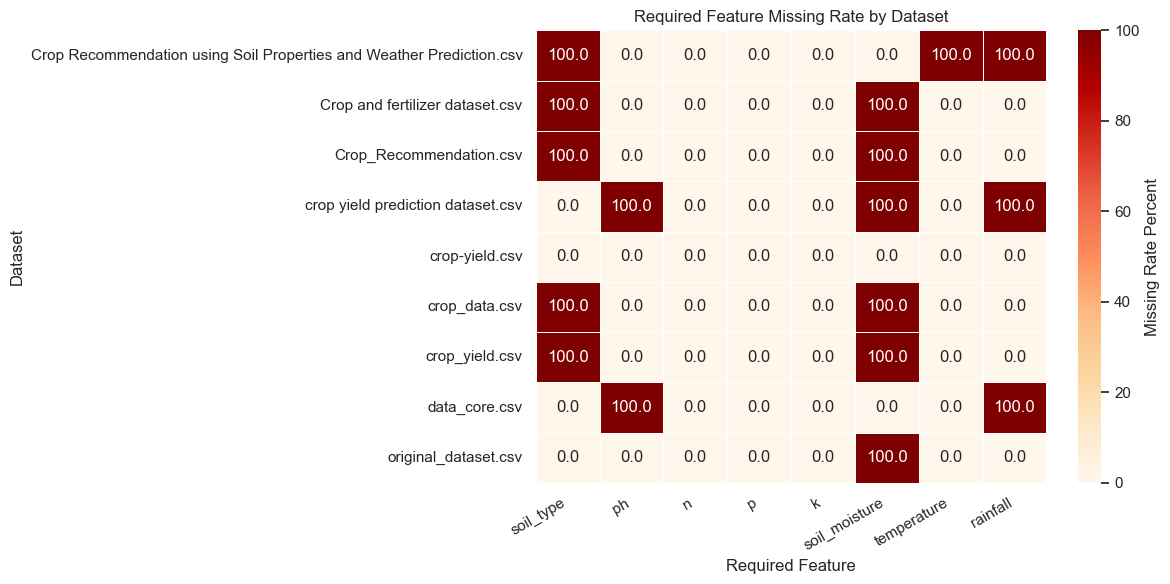

In [5]:
missing_matrix = (1 - coverage_matrix) * 100
plt.figure(figsize=(12, 6))
sns.heatmap(
    missing_matrix,
    annot=True,
    fmt=".1f",
    cmap="OrRd",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Missing Rate Percent"},
)
plt.title("Required Feature Missing Rate by Dataset")
plt.xlabel("Required Feature")
plt.ylabel("Dataset")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


## 4 Duplicate Row Analysis


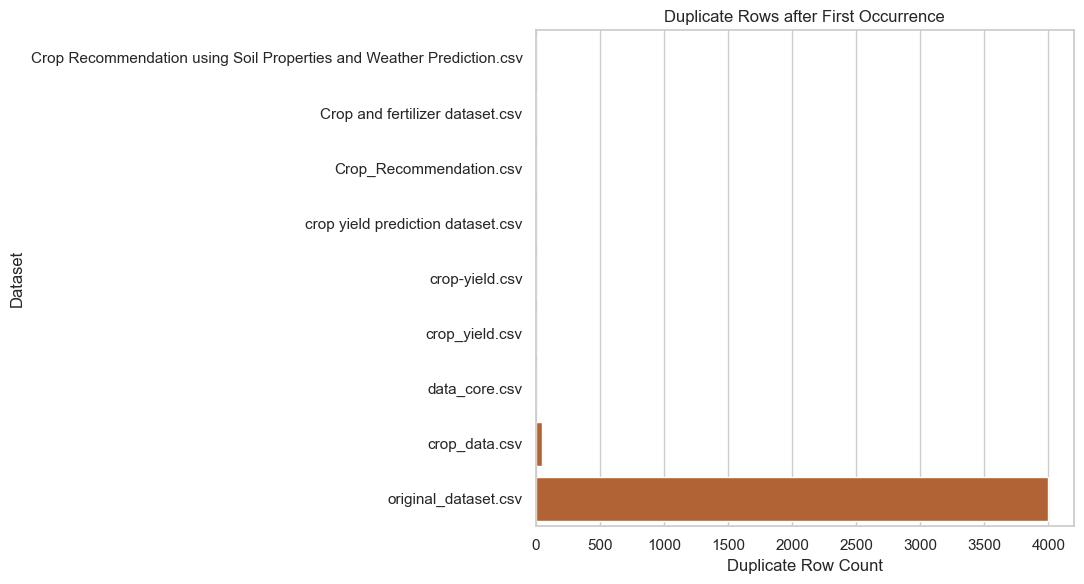

In [6]:
duplicate_plot = inventory.sort_values("raw_duplicate_rows_after_first", ascending=True)
plt.figure(figsize=(11, 6))
sns.barplot(
    data=duplicate_plot,
    x="raw_duplicate_rows_after_first",
    y="source_file",
    color="#c65d21",
)
plt.title("Duplicate Rows after First Occurrence")
plt.xlabel("Duplicate Row Count")
plt.ylabel("Dataset")
plt.tight_layout()
plt.show()


In [7]:
inventory[
    [
        "source_file", "rows", "raw_duplicate_rows_after_first",
        "raw_duplicate_rows_in_groups", "canonical_duplicate_rows_in_groups"
    ]
].sort_values("raw_duplicate_rows_after_first", ascending=False)


,source_file,rows,raw_duplicate_rows_after_first,raw_duplicate_rows_in_groups,canonical_duplicate_rows_in_groups
8,original_dataset.csv,5000,4000,4907,4907
5,crop_data.csv,694,48,93,93
0,Crop Recommendation using Soil Properties and Weather Prediction.csv,3867,0,0,2
1,Crop and fertilizer dataset.csv,4513,0,0,130
2,Crop_Recommendation.csv,2200,0,0,0
3,crop yield prediction dataset.csv,246091,0,0,219348
4,crop-yield.csv,10000,0,0,0
6,crop_yield.csv,19689,0,0,6467
7,data_core.csv,8000,0,0,0


## 5 Crop Class Balance


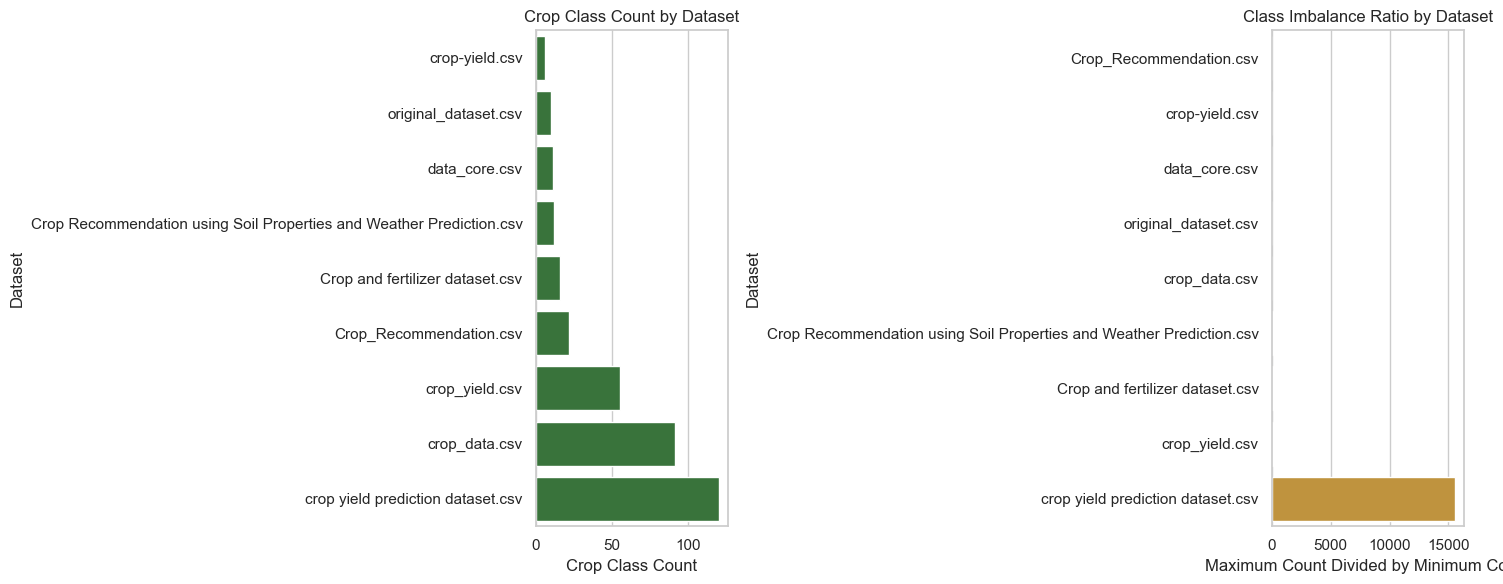

In [8]:
class_balance = inventory.copy()
class_balance["imbalance_ratio"] = (
    class_balance["maximum_class_count"] / class_balance["minimum_class_count"]
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(
    data=class_balance.sort_values("crop_classes"),
    x="crop_classes",
    y="source_file",
    color=CHART_COLOR,
    ax=axes[0],
)
axes[0].set_title("Crop Class Count by Dataset")
axes[0].set_xlabel("Crop Class Count")
axes[0].set_ylabel("Dataset")

sns.barplot(
    data=class_balance.sort_values("imbalance_ratio"),
    x="imbalance_ratio",
    y="source_file",
    color="#d49a28",
    ax=axes[1],
)
axes[1].set_title("Class Imbalance Ratio by Dataset")
axes[1].set_xlabel("Maximum Count Divided by Minimum Count")
axes[1].set_ylabel("Dataset")
plt.tight_layout()
plt.show()


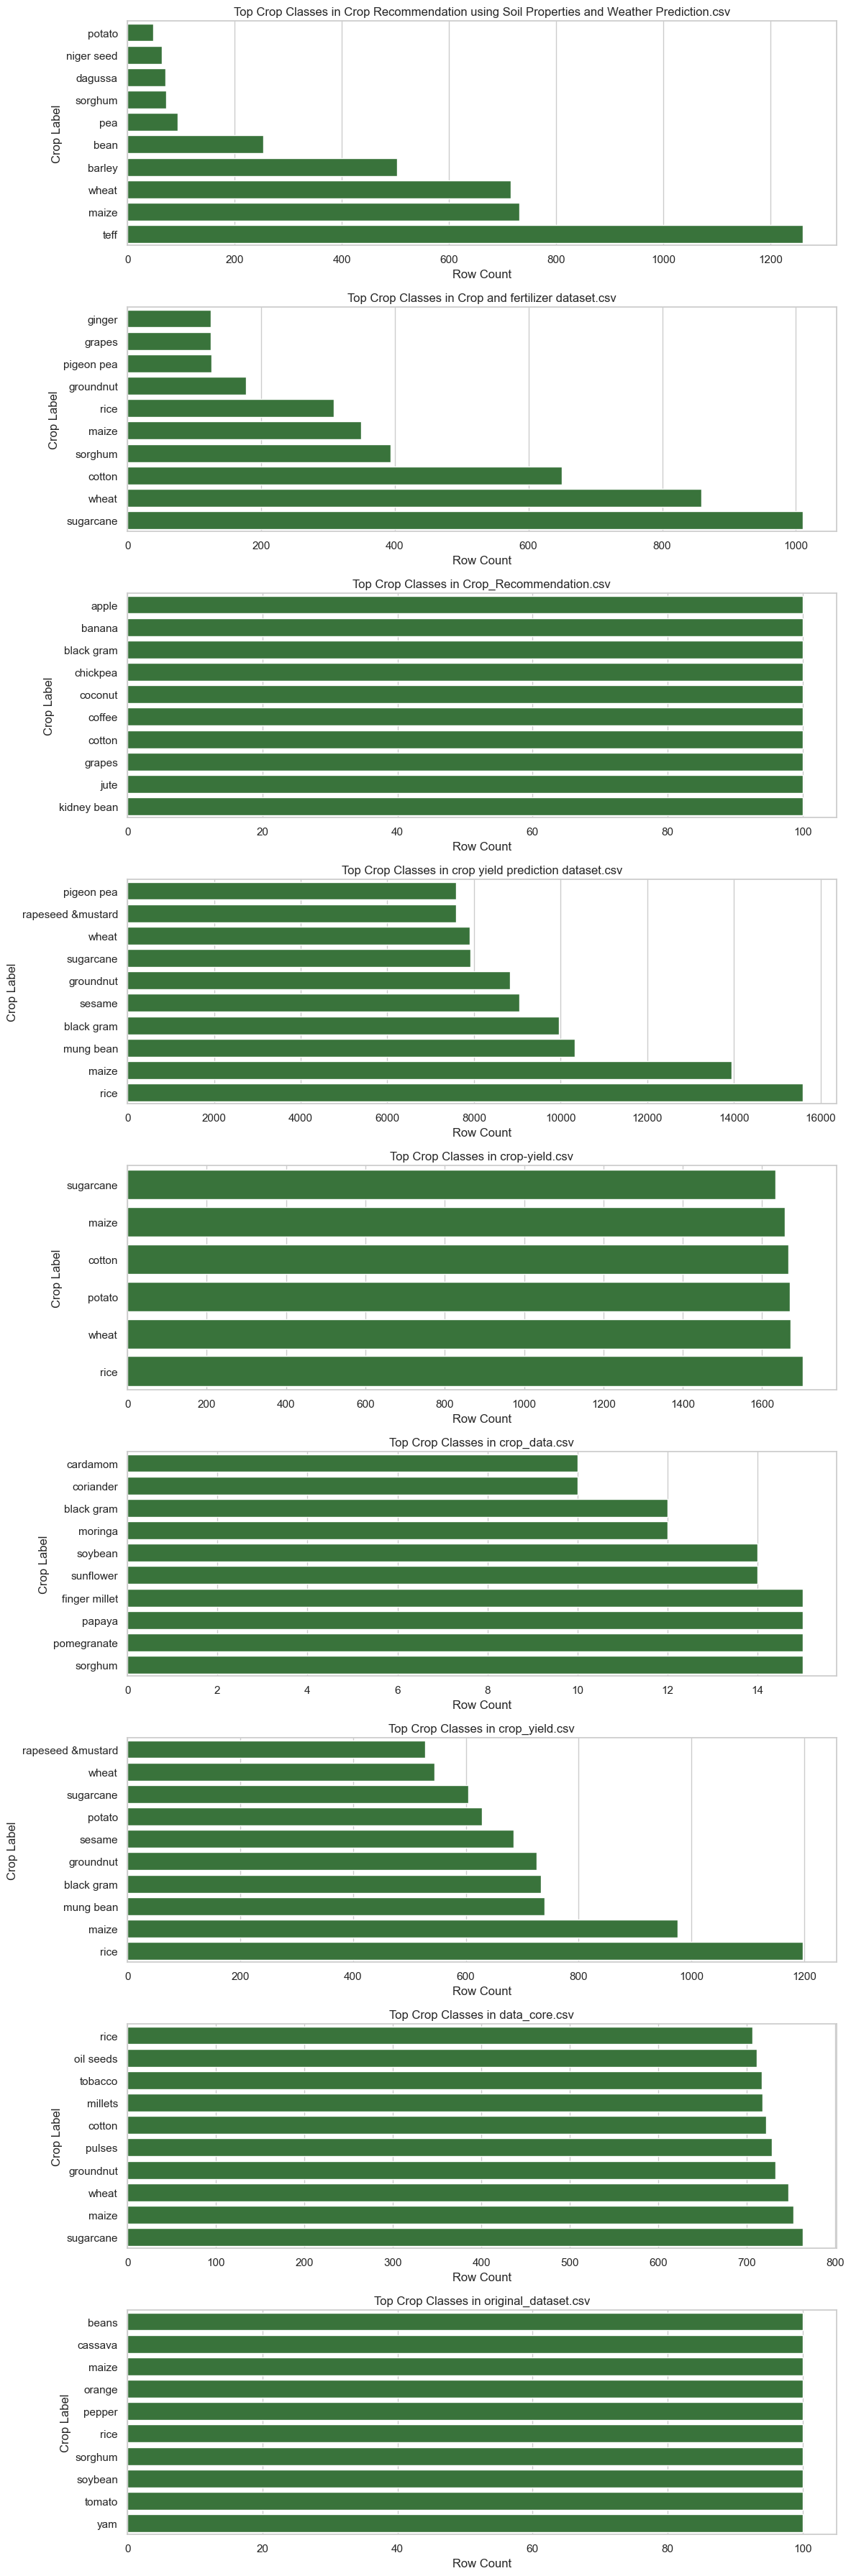

In [9]:
crop_mapping = pd.read_csv(METADATA_DIR / "crop_label_mapping.csv")
top_crops = (
    crop_mapping.groupby(["source_file", "crop_label"], as_index=False)["row_count"]
    .sum()
    .sort_values(["source_file", "row_count"], ascending=[True, False])
    .groupby("source_file")
    .head(10)
)

sources = top_crops["source_file"].unique()
fig, axes = plt.subplots(len(sources), 1, figsize=(12, 4 * len(sources)))
if len(sources) == 1:
    axes = [axes]

for axis, source in zip(axes, sources):
    subset = top_crops[top_crops["source_file"] == source].sort_values("row_count")
    sns.barplot(data=subset, x="row_count", y="crop_label", color=CHART_COLOR, ax=axis)
    axis.set_title("Top Crop Classes in " + source)
    axis.set_xlabel("Row Count")
    axis.set_ylabel("Crop Label")

plt.tight_layout()
plt.show()


## 6 Crop Label Overlap


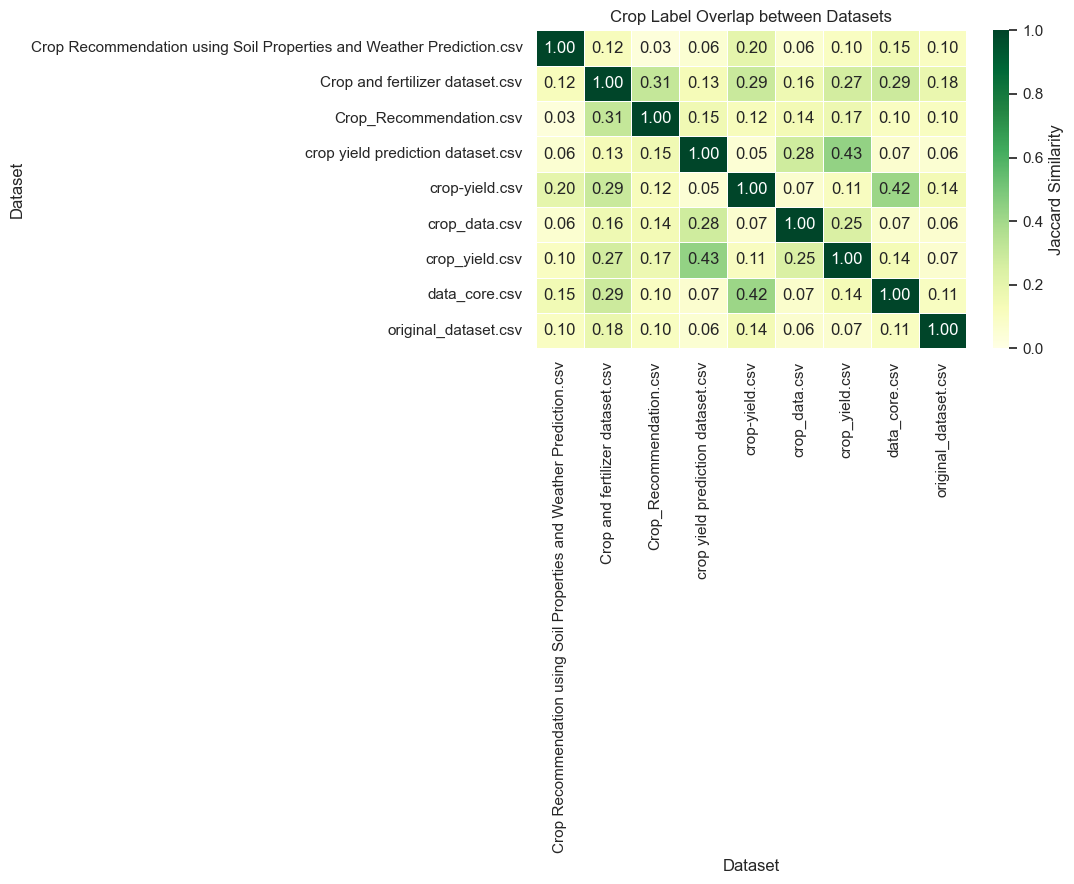

In [10]:
crop_sets = {
    source: set(group["crop_label"].dropna())
    for source, group in crop_mapping.groupby("source_file")
}
source_names = list(crop_sets)
overlap = pd.DataFrame(index=source_names, columns=source_names, dtype=float)

for left in source_names:
    for right in source_names:
        union = crop_sets[left] | crop_sets[right]
        overlap.loc[left, right] = (
            len(crop_sets[left] & crop_sets[right]) / len(union) if union else 0
        )

plt.figure(figsize=(11, 9))
sns.heatmap(
    overlap,
    annot=True,
    fmt=".2f",
    cmap=PALETTE,
    vmin=0,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Jaccard Similarity"},
)
plt.title("Crop Label Overlap between Datasets")
plt.xlabel("Dataset")
plt.ylabel("Dataset")
plt.tight_layout()
plt.show()


## 7 Load Canonical Source Tables


In [11]:
processed_files = sorted(CLEANED_BY_SOURCE_DIR.glob("*.csv"))
source_frames = {}

for path in processed_files:
    frame = pd.read_csv(path, low_memory=False)
    source_name = frame["source_file"].iloc[0]
    source_frames[source_name] = frame

print("Loaded cleaned source tables", len(source_frames))
print("Loaded cleaned rows", sum(len(frame) for frame in source_frames.values()))


Loaded cleaned source tables 9
Loaded cleaned rows 296006


## 8 NPK Distribution Review

The source units are not verified. These plots compare the stored values but do not claim that the values are directly compatible.


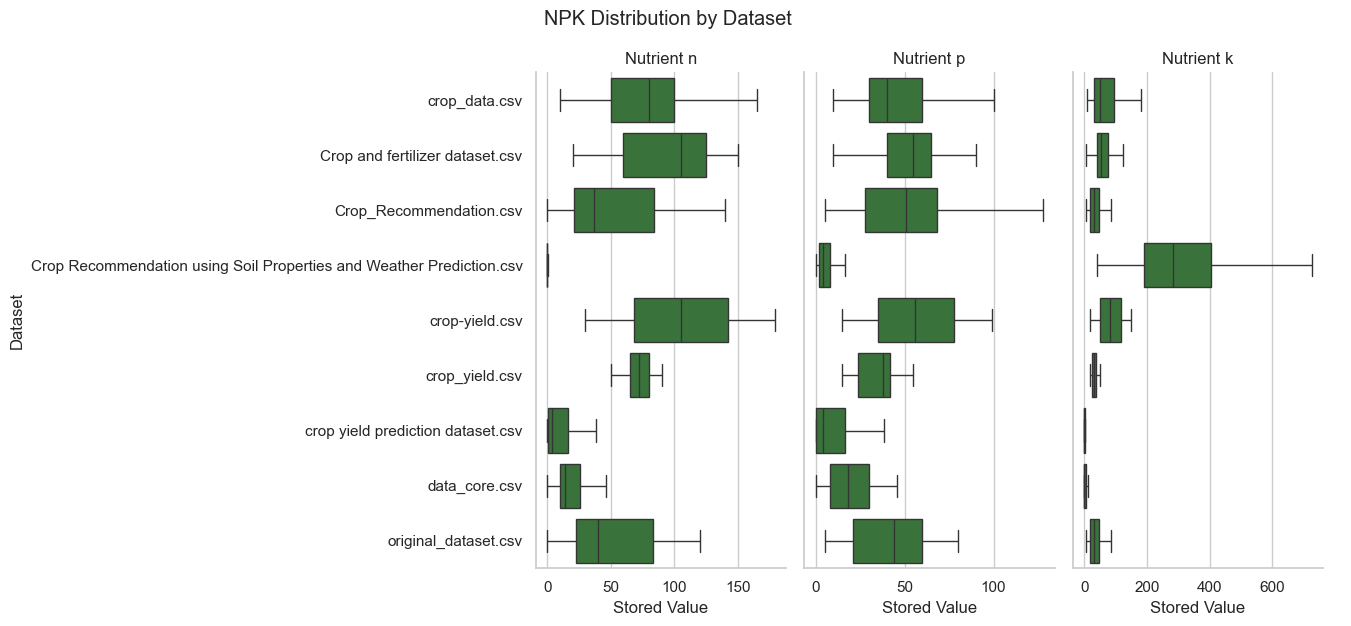

In [12]:
npk_parts = []
for source, frame in source_frames.items():
    sample = frame[["n", "p", "k"]].dropna(how="all")
    if len(sample) > 5000:
        sample = sample.sample(5000, random_state=42)
    sample = sample.assign(source_file=source)
    npk_parts.append(sample)

npk_long = pd.concat(npk_parts, ignore_index=True).melt(
    id_vars="source_file",
    value_vars=["n", "p", "k"],
    var_name="nutrient",
    value_name="value",
).dropna()

g = sns.catplot(
    data=npk_long,
    x="value",
    y="source_file",
    col="nutrient",
    kind="box",
    showfliers=False,
    sharex=False,
    height=6,
    aspect=0.75,
    color=CHART_COLOR,
)
g.set_axis_labels("Stored Value", "Dataset")
g.set_titles("Nutrient {col_name}")
g.fig.suptitle("NPK Distribution by Dataset", y=1.04)
plt.show()


## 9 Temperature Rainfall and Soil Moisture Review


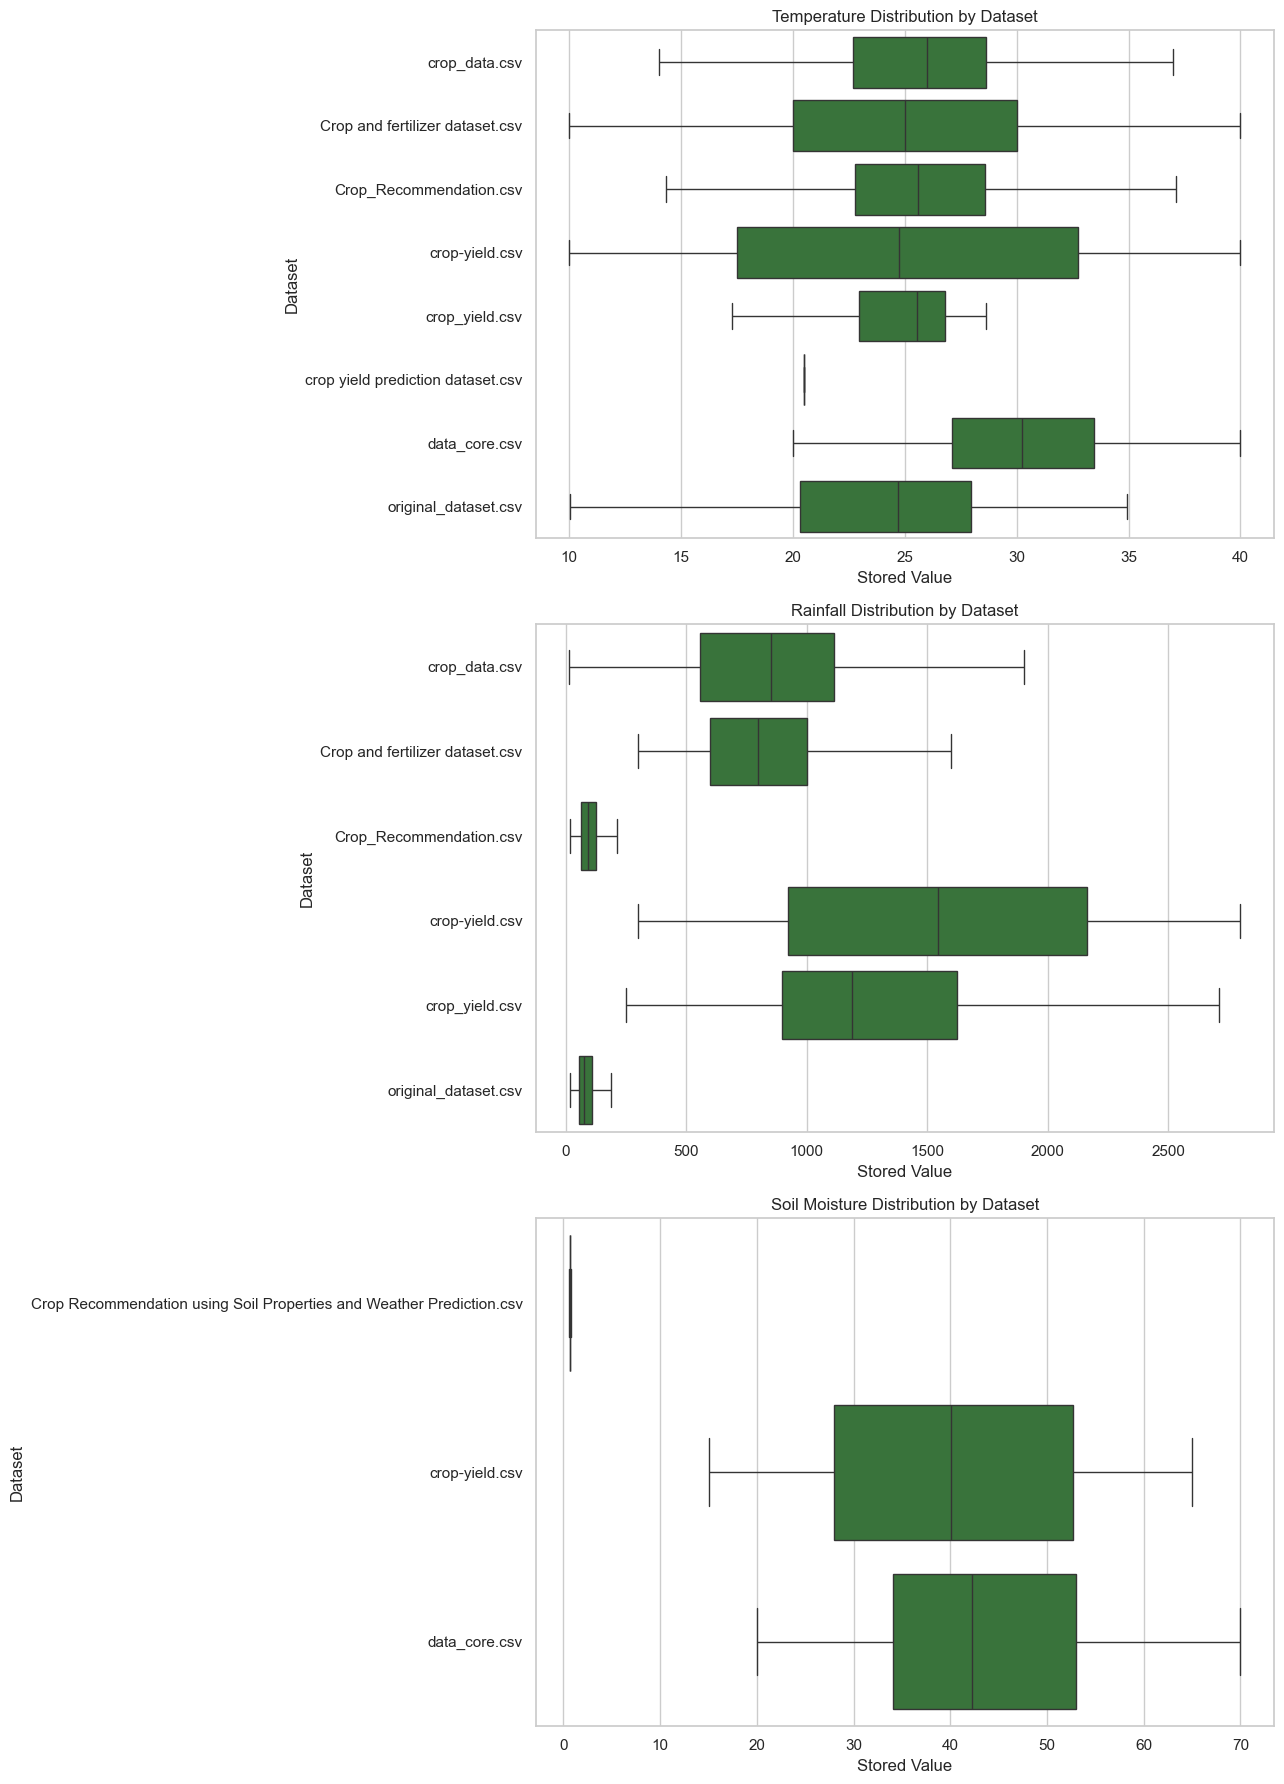

In [13]:
def sampled_feature(feature, sample_size=5000):
    parts = []
    for source, frame in source_frames.items():
        values = frame[[feature]].dropna()
        if len(values) > sample_size:
            values = values.sample(sample_size, random_state=42)
        if not values.empty:
            values = values.assign(source_file=source)
            parts.append(values)
    return pd.concat(parts, ignore_index=True) if parts else pd.DataFrame()

fig, axes = plt.subplots(3, 1, figsize=(13, 18))
for axis, feature, title in zip(
    axes,
    ["temperature", "rainfall", "soil_moisture"],
    [
        "Temperature Distribution by Dataset",
        "Rainfall Distribution by Dataset",
        "Soil Moisture Distribution by Dataset",
    ],
):
    values = sampled_feature(feature)
    sns.boxplot(
        data=values,
        x=feature,
        y="source_file",
        showfliers=False,
        color=CHART_COLOR,
        ax=axis,
    )
    axis.set_title(title)
    axis.set_xlabel("Stored Value")
    axis.set_ylabel("Dataset")

plt.tight_layout()
plt.show()


## 10 Soil Type Review


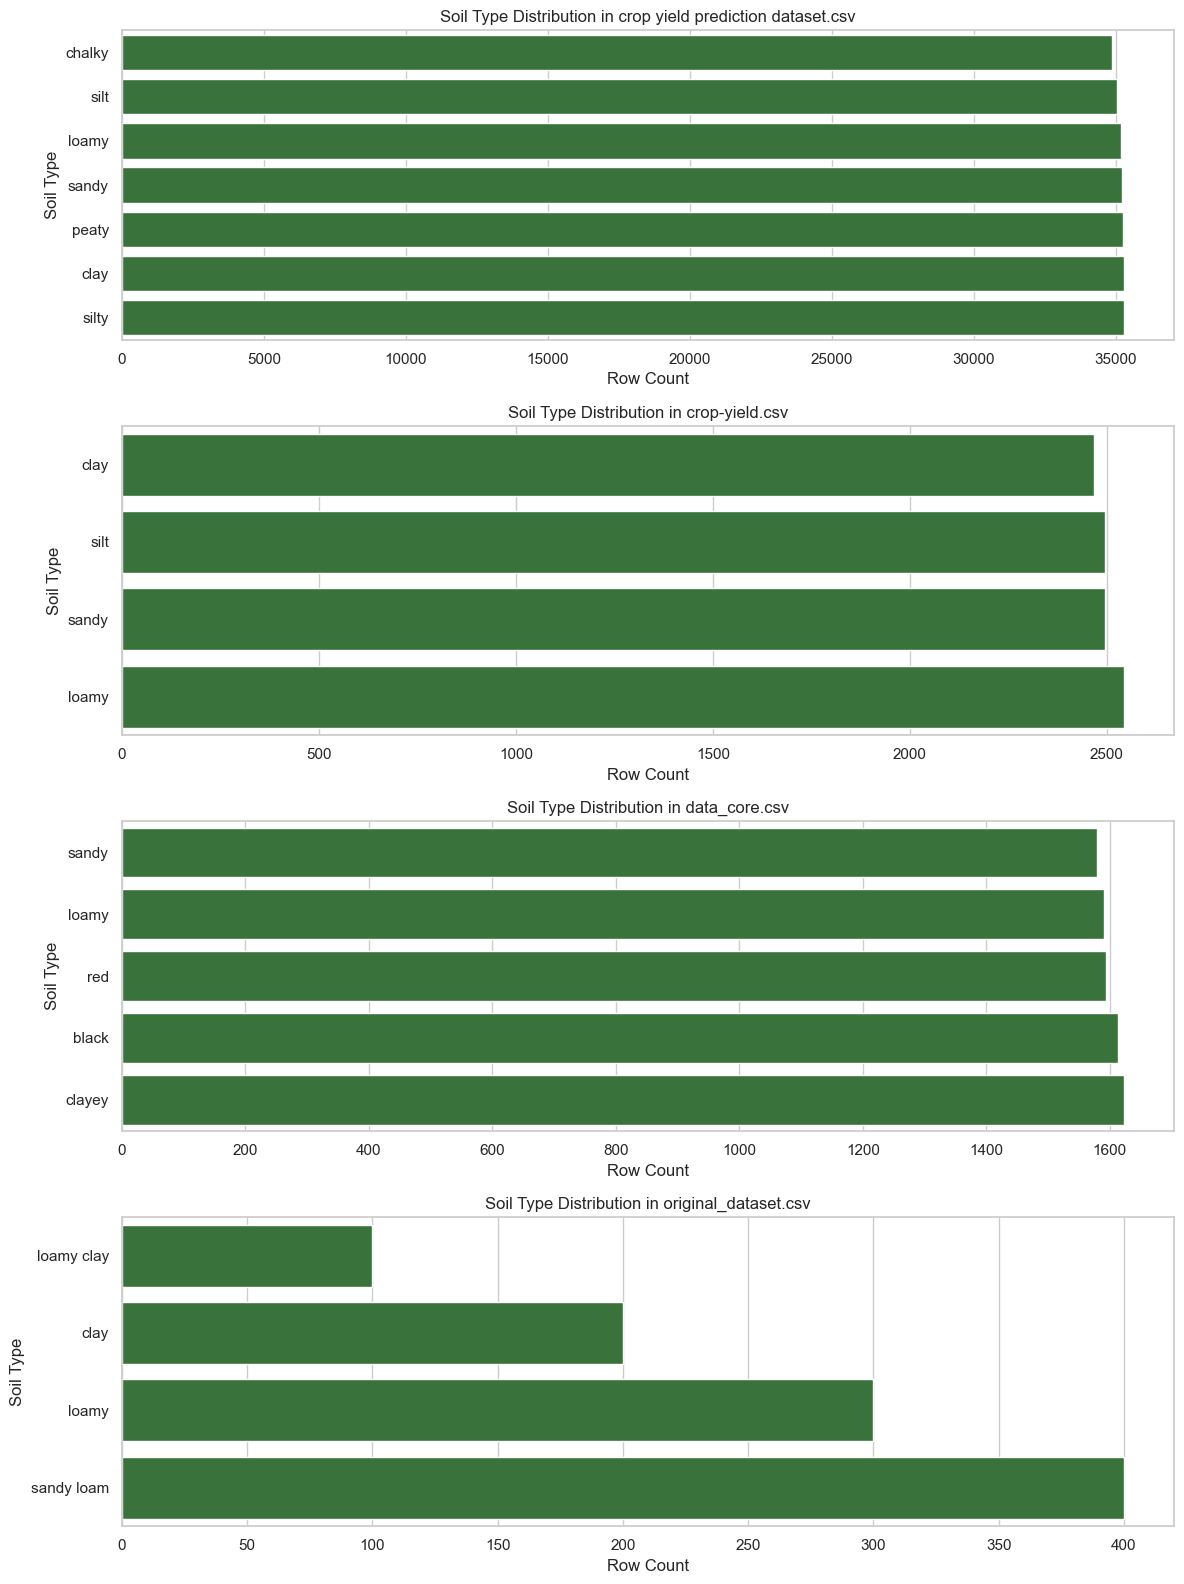

In [14]:
soil_parts = []
for source, frame in source_frames.items():
    values = frame[["soil_type"]].dropna()
    if not values.empty:
        values = values.assign(source_file=source)
        soil_parts.append(values)

soil_counts = (
    pd.concat(soil_parts, ignore_index=True)
    .groupby(["source_file", "soil_type"])
    .size()
    .rename("row_count")
    .reset_index()
)

sources = soil_counts["source_file"].unique()
fig, axes = plt.subplots(len(sources), 1, figsize=(12, 4 * len(sources)))
if len(sources) == 1:
    axes = [axes]

for axis, source in zip(axes, sources):
    subset = soil_counts[soil_counts["source_file"] == source].sort_values("row_count")
    sns.barplot(data=subset, x="row_count", y="soil_type", color=CHART_COLOR, ax=axis)
    axis.set_title("Soil Type Distribution in " + source)
    axis.set_xlabel("Row Count")
    axis.set_ylabel("Soil Type")

plt.tight_layout()
plt.show()


## 11 Suspicious Field Review


In [15]:
raw_large = pd.read_csv(
    PROJECT_ROOT / "dataset" / "crop yield prediction dataset.csv",
    usecols=["precipitation", "humidity", "production"],
    low_memory=False,
)

suspicious_summary = pd.DataFrame(
    {
        "field": ["precipitation", "humidity", "production"],
        "minimum": [
            pd.to_numeric(raw_large["precipitation"], errors="coerce").min(),
            pd.to_numeric(raw_large["humidity"], errors="coerce").min(),
            pd.to_numeric(raw_large["production"], errors="coerce").min(),
        ],
        "median": [
            pd.to_numeric(raw_large["precipitation"], errors="coerce").median(),
            pd.to_numeric(raw_large["humidity"], errors="coerce").median(),
            pd.to_numeric(raw_large["production"], errors="coerce").median(),
        ],
        "maximum": [
            pd.to_numeric(raw_large["precipitation"], errors="coerce").max(),
            pd.to_numeric(raw_large["humidity"], errors="coerce").max(),
            pd.to_numeric(raw_large["production"], errors="coerce").max(),
        ],
        "non_numeric_count": [
            pd.to_numeric(raw_large["precipitation"], errors="coerce").isna().sum(),
            pd.to_numeric(raw_large["humidity"], errors="coerce").isna().sum(),
            pd.to_numeric(raw_large["production"], errors="coerce").isna().sum(),
        ],
        "decision": [
            "Do not map to rainfall",
            "Do not map to soil moisture",
            "Exclude from recommendation inputs",
        ],
    }
)
suspicious_summary


,field,minimum,median,maximum,non_numeric_count,decision
0,precipitation,1009.0,1013.011877,1.023000e+03,0,Do not map to rainfall
1,humidity,37.0,64.876363,9.600000e+01,0,Do not map to soil moisture
2,production,0.0,729.000000,1.250800e+09,3727,Exclude from recommendation inputs


## 12 Feature Dictionary and Data Decisions


In [16]:
feature_dictionary = pd.read_csv(METADATA_DIR / "source_feature_dictionary.csv")
feature_dictionary.sort_values(["canonical_feature", "source_file"])


,source_file,canonical_feature,original_column,available,transformation,unit_status,semantic_status,approved_for_training
4,Crop Recommendation using Soil Properties and Weather Prediction.csv,k,k,True,numeric_coercion_only,unverified,direct_name_match,False
12,Crop and fertilizer dataset.csv,k,k,True,numeric_coercion_only,unverified,direct_name_match,False
20,Crop_Recommendation.csv,k,k,True,numeric_coercion_only,unverified,direct_name_match,False
28,crop yield prediction dataset.csv,k,K,True,numeric_coercion_only,unverified,direct_name_match,False
36,crop-yield.csv,k,k,True,numeric_coercion_only,unverified,direct_name_match,False
...,...,...,...,...,...,...,...,...
38,crop-yield.csv,temperature,temperature,True,numeric_coercion_only,unverified,direct_name_match,False
46,crop_data.csv,temperature,temperature,True,numeric_coercion_only,unverified,direct_name_match,False
54,crop_yield.csv,temperature,temperature,True,numeric_coercion_only,unverified,direct_name_match,False
62,data_core.csv,temperature,temperature,True,numeric_coercion_only,unverified,direct_name_match,False


In [17]:
inventory[
    ["source_file", "quality_tier", "training_status", "review_note"]
].sort_values(["training_status", "source_file"])


,source_file,quality_tier,training_status,review_note
2,Crop_Recommendation.csv,prototype_candidate,candidate_after_validation,Atmospheric humidity is excluded because it is not soil moisture. Soil type and soil moisture are unavailable.
4,crop-yield.csv,complete_but_low_signal,exclude_until_signal_review,"All required fields are present, but the initial crop classification diagnostic was near the majority baseline. Trea..."
3,crop yield prediction dataset.csv,quarantine,exclude_v1,Precipitation values near 1009 to 1023 are not mapped to rainfall. Atmospheric humidity is excluded. PH and soil moi...
6,crop_yield.csv,yield_reference,exclude_v1,Atmospheric humidity is excluded. Soil type and soil moisture are unavailable. Yield and production fields are not r...
8,original_dataset.csv,quarantine,exclude_v1,"Soil moisture is unavailable. The source contains extensive duplicate rows, and soil type is deterministic for each ..."
0,Crop Recommendation using Soil Properties and Weather Prediction.csv,needs_semantic_verification,hold,Seasonal temperature and precipitation are not converted to annual temperature or rainfall. Soil color is not mapped...
1,Crop and fertilizer dataset.csv,reference_only,hold,Soil color is not mapped to soil type. Soil moisture is unavailable. NPK may represent fertilizer requirements rathe...
5,crop_data.csv,reference_only,hold,Soil type and soil moisture are unavailable. The source has many crop classes with very small support and contains d...
7,data_core.csv,reference_only,hold,PH and rainfall are unavailable. The initial crop classification diagnostic was near the majority baseline.


## 13 Cleaning Integrity


In [18]:
cleaning_report = pd.read_csv(METADATA_DIR / "cleaning_report.csv")
cleaning_report.sort_values("raw_duplicate_rows_after_first", ascending=False)


,source_file,rows,raw_duplicate_rows_after_first,cleaned_rows,non_specific_crop_rows,physical_range_error_rows,cleaned_conflicting_feature_label_rows,cleaned_conflicting_feature_groups,row_reconciliation_passed,value_imputation_applied,unit_conversion_applied,outlier_deletion_applied
8,original_dataset.csv,5000,4000,1000,0,0,0,0,True,False,False,False
5,crop_data.csv,694,48,646,0,0,24,12,True,False,False,False
0,Crop Recommendation using Soil Properties and Weather Prediction.csv,3867,0,3867,26,0,5,2,True,False,False,False
1,Crop and fertilizer dataset.csv,4513,0,4513,0,0,14,7,True,False,False,False
2,Crop_Recommendation.csv,2200,0,2200,0,0,0,0,True,False,False,False
3,crop yield prediction dataset.csv,246091,0,246091,19506,0,238423,3057,True,False,False,False
4,crop-yield.csv,10000,0,10000,0,0,0,0,True,False,False,False
6,crop_yield.csv,19689,0,19689,1902,0,19689,657,True,False,False,False
7,data_core.csv,8000,0,8000,2157,0,0,0,True,False,False,False


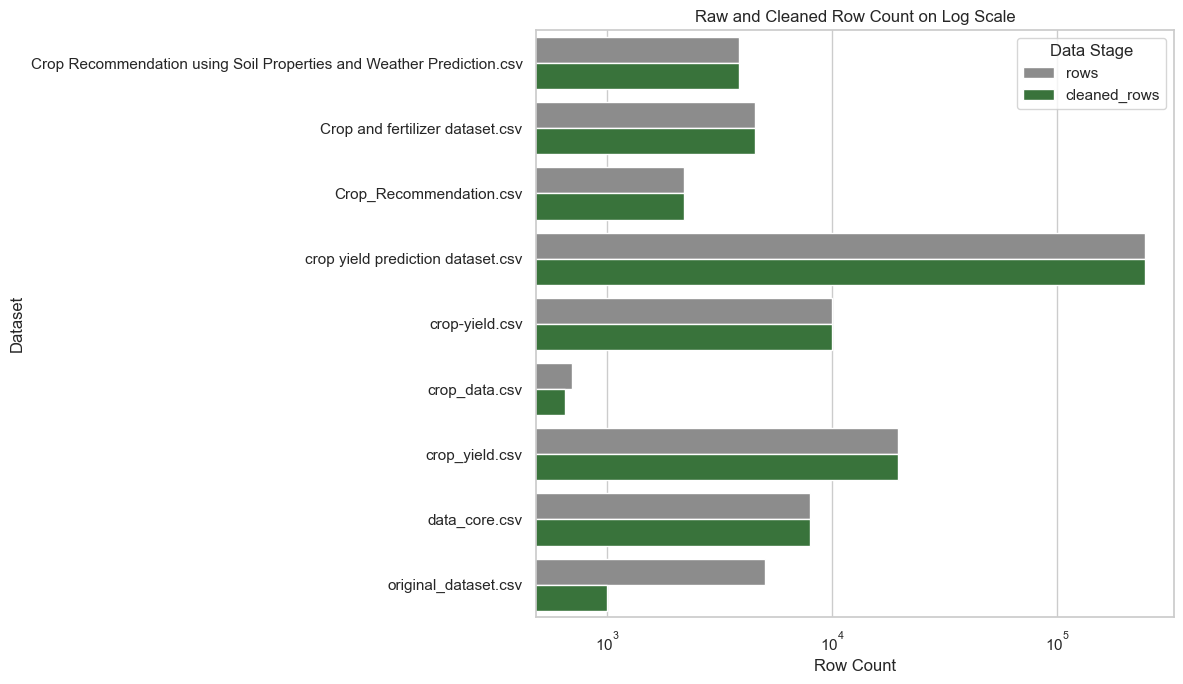

In [19]:
cleaning_long = cleaning_report.melt(
    id_vars="source_file",
    value_vars=["rows", "cleaned_rows"],
    var_name="data_stage",
    value_name="row_count",
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=cleaning_long,
    x="row_count",
    y="source_file",
    hue="data_stage",
    palette=["#8c8c8c", CHART_COLOR],
)
plt.xscale("log")
plt.title("Raw and Cleaned Row Count on Log Scale")
plt.xlabel("Row Count")
plt.ylabel("Dataset")
plt.legend(title="Data Stage")
plt.tight_layout()
plt.show()


## 14 Unit Review


In [20]:
unit_review = pd.read_csv(METADATA_DIR / "unit_review.csv")
unit_review[
    [
        "source_file", "canonical_feature", "stored_unit", "unit_status",
        "conversion_applied", "approved_for_cross_source_merge", "review_note"
    ]
].sort_values(["canonical_feature", "source_file"])


,source_file,canonical_feature,stored_unit,unit_status,conversion_applied,approved_for_cross_source_merge,review_note
4,Crop Recommendation using Soil Properties and Weather Prediction.csv,k,unknown,unverified_no_conversion,False,False,Dataset description confirms the feature domain but does not publish its unit on the data card.
12,Crop and fertilizer dataset.csv,k,rate_unspecified,unverified_no_conversion,False,False,Dataset card calls the field a rate but does not publish a unit.
20,Crop_Recommendation.csv,k,soil_nutrient_ratio,verified_from_dataset_card,False,False,Dataset card defines K as potassium ratio in soil.
28,crop yield prediction dataset.csv,k,unknown,unverified_no_conversion,False,False,The local file does not provide a trustworthy unit definition.
36,crop-yield.csv,k,unknown,unverified_no_conversion,False,False,The local file does not provide a trustworthy unit definition.
...,...,...,...,...,...,...,...
38,crop-yield.csv,temperature,unknown,unverified_no_conversion,False,False,The local file does not provide a trustworthy unit definition.
46,crop_data.csv,temperature,unknown,unverified_no_conversion,False,False,The local file does not provide a trustworthy unit definition.
54,crop_yield.csv,temperature,unknown,unverified_no_conversion,False,False,The local file does not provide a trustworthy unit definition.
62,data_core.csv,temperature,unknown,unverified_no_conversion,False,False,The local file does not provide a trustworthy unit definition.


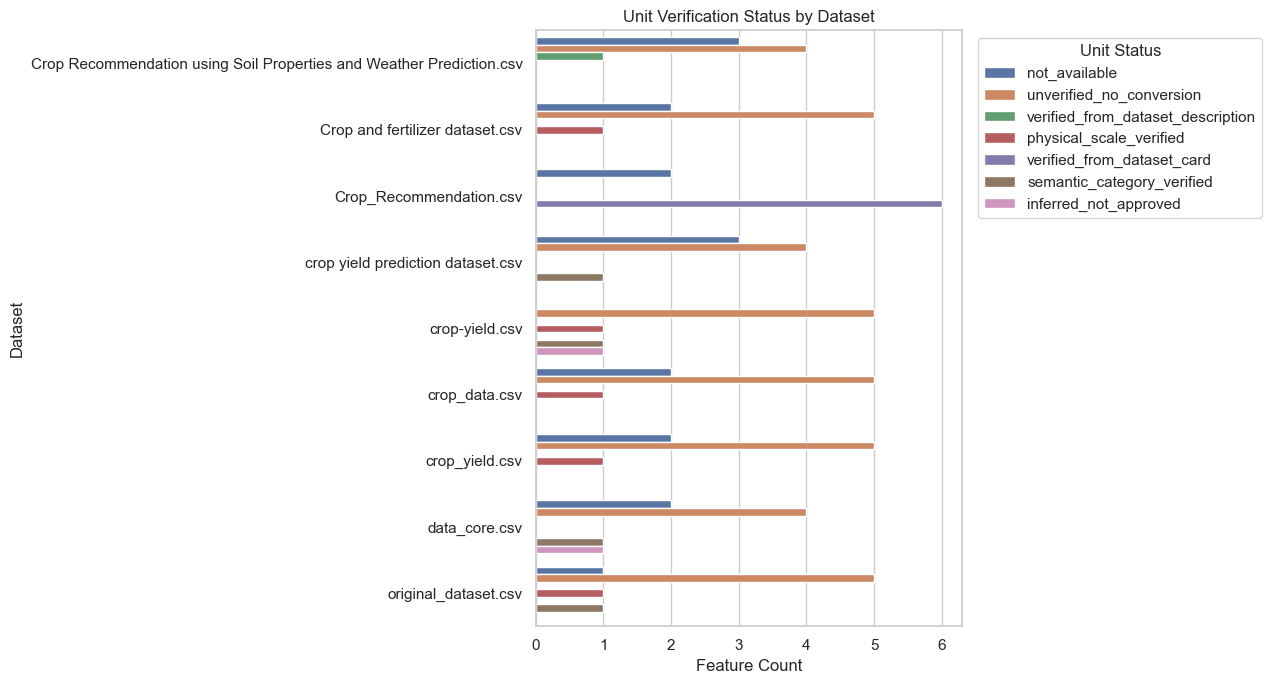

In [21]:
unit_status_counts = (
    unit_review.groupby(["source_file", "unit_status"])
    .size()
    .rename("feature_count")
    .reset_index()
)

plt.figure(figsize=(13, 7))
sns.barplot(
    data=unit_status_counts,
    x="feature_count",
    y="source_file",
    hue="unit_status",
)
plt.title("Unit Verification Status by Dataset")
plt.xlabel("Feature Count")
plt.ylabel("Dataset")
plt.legend(title="Unit Status", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## 15 Approved Crop Label Mapping


In [22]:
mapping_changes = crop_mapping[
    crop_mapping["crop_mapping_rule"].ne("identity")
].copy()
mapping_changes[
    [
        "source_file", "crop_label_raw", "crop_label_normalized", "crop_label",
        "crop_mapping_rule", "crop_mapping_status", "is_specific_crop_label", "row_count"
    ]
].sort_values(["crop_mapping_status", "crop_label", "source_file"])


,source_file,crop_label_raw,crop_label_normalized,crop_label,crop_mapping_rule,crop_mapping_status,is_specific_crop_label,row_count
189,crop_data.csv,bittergourd,bittergourd,bitter gourd,spacing_variant,approved,True,5
26,Crop and fertilizer dataset.csv,urad,urad,black gram,common_name_synonym,approved,True,99
30,Crop_Recommendation.csv,blackgram,blackgram,black gram,spacing_variant,approved,True,100
66,crop yield prediction dataset.csv,Blackgram,blackgram,black gram,spacing_variant,approved,True,118
166,crop yield prediction dataset.csv,Urad,urad,black gram,common_name_synonym,approved,True,9850
...,...,...,...,...,...,...,...,...
143,crop yield prediction dataset.csv,Redish,redish,redish,non_specific_or_ambiguous_target,excluded,False,61
144,crop yield prediction dataset.csv,Ribed Guard,ribed guard,ribed guard,non_specific_or_ambiguous_target,excluded,False,38
153,crop yield prediction dataset.csv,Small millets,small millets,small millets,non_specific_or_ambiguous_target,excluded,False,4652
322,crop_yield.csv,small_millets,small millets,small millets,non_specific_or_ambiguous_target,excluded,False,485


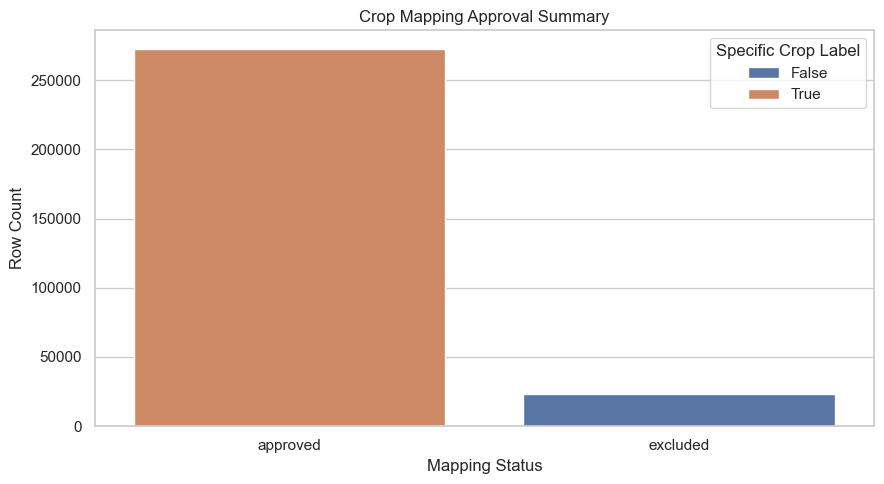

In [23]:
mapping_summary = (
    crop_mapping.groupby(["crop_mapping_status", "is_specific_crop_label"])["row_count"]
    .sum()
    .rename("row_count")
    .reset_index()
)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=mapping_summary,
    x="crop_mapping_status",
    y="row_count",
    hue="is_specific_crop_label",
)
plt.title("Crop Mapping Approval Summary")
plt.xlabel("Mapping Status")
plt.ylabel("Row Count")
plt.legend(title="Specific Crop Label")
plt.tight_layout()
plt.show()


## 16 Duplicate Leakage Risk


In [24]:
fingerprint_rows = []
for source, frame in source_frames.items():
    fingerprint_rows.append(
        {
            "source_file": source,
            "cleaned_rows": len(frame),
            "unique_model_fingerprints": frame["feature_fingerprint"].nunique(),
            "model_fingerprint_duplicates_after_first": frame["feature_fingerprint"].duplicated().sum(),
            "conflicting_input_label_rows": frame["has_conflicting_crop_labels_for_features"].sum(),
            "conflicting_input_label_groups": frame.loc[
                frame["has_conflicting_crop_labels_for_features"], "feature_fingerprint"
            ].nunique(),
            "rows_in_cross_source_fingerprint_groups": frame[
                "global_feature_fingerprint_group_size"
            ].gt(1).sum(),
        }
    )

fingerprint_summary = pd.DataFrame(fingerprint_rows)
fingerprint_summary.sort_values("model_fingerprint_duplicates_after_first", ascending=False)


,source_file,cleaned_rows,unique_model_fingerprints,model_fingerprint_duplicates_after_first,conflicting_input_label_rows,conflicting_input_label_groups,rows_in_cross_source_fingerprint_groups
6,crop yield prediction dataset.csv,246091,10681,235410,238423,3057,238511
5,crop_yield.csv,19689,657,19032,19689,657,19689
1,Crop and fertilizer dataset.csv,4513,4436,77,14,7,144
0,crop_data.csv,646,634,12,24,12,24
3,Crop Recommendation using Soil Properties and Weather Prediction.csv,3867,3864,3,5,2,5
2,Crop_Recommendation.csv,2200,2200,0,0,0,0
4,crop-yield.csv,10000,10000,0,0,0,0
7,data_core.csv,8000,8000,0,0,0,0
8,original_dataset.csv,1000,1000,0,0,0,0


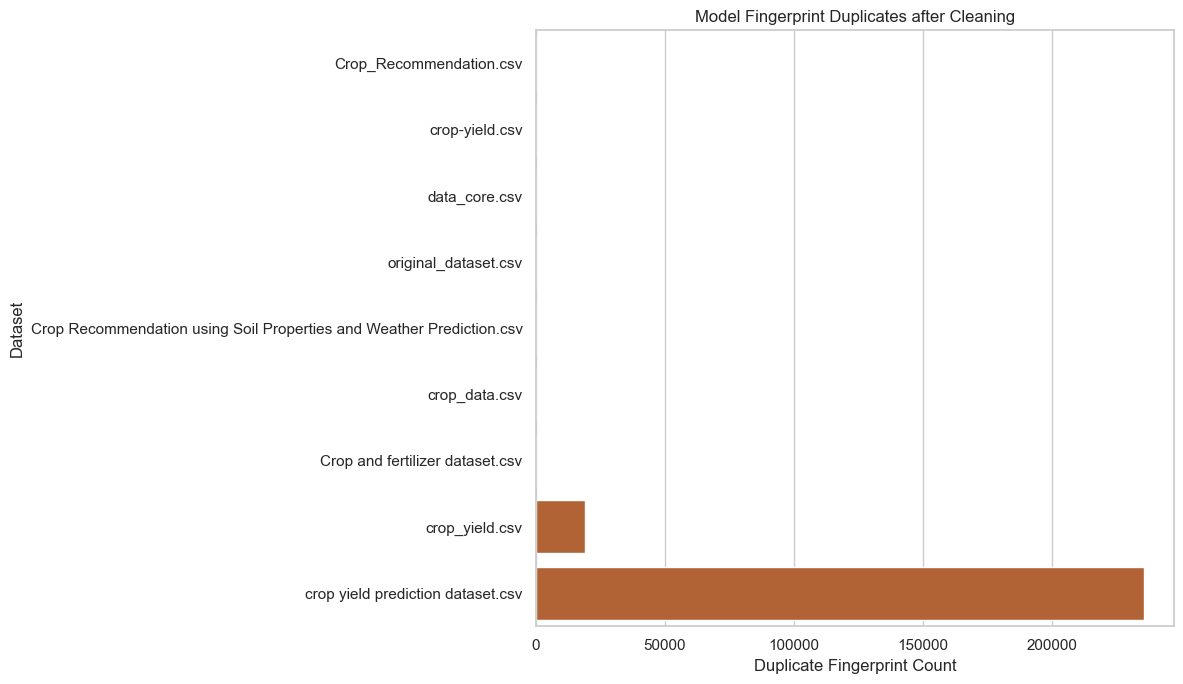

In [25]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=fingerprint_summary.sort_values("model_fingerprint_duplicates_after_first"),
    x="model_fingerprint_duplicates_after_first",
    y="source_file",
    color="#c65d21",
)
plt.title("Model Fingerprint Duplicates after Cleaning")
plt.xlabel("Duplicate Fingerprint Count")
plt.ylabel("Dataset")
plt.tight_layout()
plt.show()


## 17 Data Quality Gate


In [26]:
quality_gate = pd.read_csv(METADATA_DIR / "data_quality_gate.csv")
quality_gate.sort_values(["approved_for_six_feature_prototype", "source_file"], ascending=[False, True])


,source_file,cleaning_reconciliation_passed,exact_duplicates_removed_from_cleaned_copy,physical_range_error_rows,non_specific_crop_rows,conflicting_feature_label_rows,conflicting_feature_groups,verified_required_unit_count,has_complete_eight_feature_rows,approved_for_full_eight_feature_training,approved_for_six_feature_prototype,leakage_control_required,gate_decision,gate_reason
2,Crop_Recommendation.csv,True,0,0,0,0,0,6,False,False,True,True,prototype_six_features_only,Atmospheric humidity is excluded because it is not soil moisture. Soil type and soil moisture are unavailable.
0,Crop Recommendation using Soil Properties and Weather Prediction.csv,True,0,0,26,5,2,1,False,False,False,True,hold_or_exclude_pending_modeling_strategy,Seasonal temperature and precipitation are not converted to annual temperature or rainfall. Soil color is not mapped...
1,Crop and fertilizer dataset.csv,True,0,0,0,14,7,0,False,False,False,True,hold_or_exclude_pending_modeling_strategy,Soil color is not mapped to soil type. Soil moisture is unavailable. NPK may represent fertilizer requirements rathe...
3,crop yield prediction dataset.csv,True,0,0,19506,238423,3057,0,False,False,False,True,hold_or_exclude_pending_modeling_strategy,Precipitation values near 1009 to 1023 are not mapped to rainfall. Atmospheric humidity is excluded. PH and soil moi...
4,crop-yield.csv,True,0,0,0,0,0,0,True,False,False,True,hold_or_exclude_pending_modeling_strategy,"All required fields are present, but the initial crop classification diagnostic was near the majority baseline. Trea..."
5,crop_data.csv,True,48,0,0,24,12,0,False,False,False,True,hold_or_exclude_pending_modeling_strategy,Soil type and soil moisture are unavailable. The source has many crop classes with very small support and contains d...
6,crop_yield.csv,True,0,0,1902,19689,657,0,False,False,False,True,hold_or_exclude_pending_modeling_strategy,Atmospheric humidity is excluded. Soil type and soil moisture are unavailable. Yield and production fields are not r...
7,data_core.csv,True,0,0,2157,0,0,0,False,False,False,True,hold_or_exclude_pending_modeling_strategy,PH and rainfall are unavailable. The initial crop classification diagnostic was near the majority baseline.
8,original_dataset.csv,True,4000,0,0,0,0,0,False,False,False,True,hold_or_exclude_pending_modeling_strategy,"Soil moisture is unavailable. The source contains extensive duplicate rows, and soil type is deterministic for each ..."


## 18 Model Risk Audit


In [27]:
signal_audit = pd.read_csv(METADATA_DIR / "model_signal_audit.csv")
signal_audit[
    [
        "source_file", "features_used", "unique_fingerprint_rows", "classes_evaluated",
        "conflicting_input_rows_excluded", "conflicting_input_groups_excluded",
        "majority_baseline", "top_one_accuracy", "top_three_accuracy",
        "balanced_accuracy", "signal_decision"
    ]
].sort_values("top_one_accuracy", ascending=False)


,source_file,features_used,unique_fingerprint_rows,classes_evaluated,conflicting_input_rows_excluded,conflicting_input_groups_excluded,majority_baseline,top_one_accuracy,top_three_accuracy,balanced_accuracy,signal_decision
8,original_dataset.csv,soil_type|ph|n|p|k|temperature|rainfall,1000,10,0,0,0.100000,1.000000,1.000000,1.000000,possible_synthetic_or_target_encoded_pattern
2,Crop_Recommendation.csv,ph|n|p|k|temperature|rainfall,2200,22,0,0,0.045455,0.981818,1.000000,0.981818,possible_synthetic_or_target_encoded_pattern
1,Crop and fertilizer dataset.csv,ph|n|p|k|temperature|rainfall,4429,16,14,7,0.227991,0.972912,1.000000,0.962488,possible_synthetic_or_target_encoded_pattern
0,crop_data.csv,ph|n|p|k|temperature|rainfall,558,71,24,12,0.029762,0.892857,0.988095,0.894601,signal_present_requires_external_validation
3,Crop Recommendation using Soil Properties and Weather Prediction.csv,ph|n|p|k|soil_moisture,3836,11,5,2,0.328410,0.436142,0.776716,0.226314,signal_present_requires_external_validation
4,crop-yield.csv,soil_type|ph|n|p|k|soil_moisture|temperature|rainfall,10000,6,0,0,0.170333,0.161667,0.476667,0.161620,insufficient_crop_signal
7,data_core.csv,soil_type|n|p|k|soil_moisture|temperature,5843,8,0,0,0.130633,0.128922,0.373075,0.128757,insufficient_crop_signal
6,crop yield prediction dataset.csv,soil_type|n|p|k|temperature,6973,63,219559,3050,0.060229,0.026291,0.085086,0.023729,insufficient_crop_signal
5,crop_yield.csv,ph|n|p|k|temperature|rainfall,0,0,17787,657,NaN,NaN,NaN,NaN,insufficient_rows_for_diagnostic


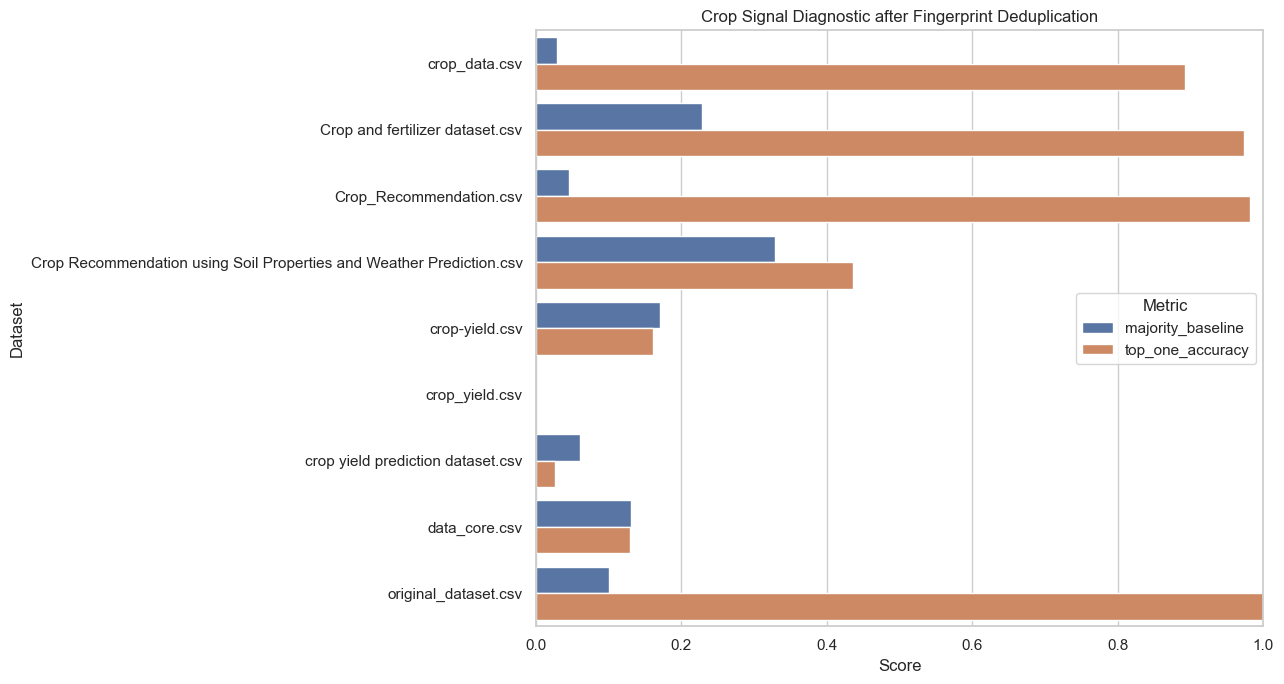

In [28]:
signal_plot = signal_audit.melt(
    id_vars="source_file",
    value_vars=["majority_baseline", "top_one_accuracy"],
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(13, 7))
sns.barplot(data=signal_plot, x="score", y="source_file", hue="metric")
plt.title("Crop Signal Diagnostic after Fingerprint Deduplication")
plt.xlabel("Score")
plt.ylabel("Dataset")
plt.xlim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


In [29]:
source_shift = pd.read_csv(METADATA_DIR / "source_shift_audit.csv")
leakage_risk = pd.read_csv(METADATA_DIR / "leakage_risk_report.csv")

display(source_shift)
leakage_risk.sort_values(
    ["model_fingerprint_duplicate_rate", "maximum_single_feature_nmi"],
    ascending=False,
)


,features_used,rows_evaluated,sources_evaluated,majority_baseline,source_top_one_accuracy,source_balanced_accuracy,dataset_shift_detected,decision
0,n|p|k|ph|temperature|rainfall,10491,6,0.285896,0.81385,0.759885,True,do_not_naively_merge_sources


,source_file,cleaned_rows,specific_crop_rows,model_fingerprint_duplicates_after_first,model_fingerprint_duplicate_rate,conflicting_input_label_rows,conflicting_input_label_groups,maximum_single_feature_nmi,maximum_nmi_feature,signal_decision,group_split_required,conflicting_labels_require_exclusion_or_resolution,single_feature_leakage_review_required,approved_for_training_after_audit
5,crop_yield.csv,19689,17787,19032,0.966631,19689,657,0.075652,ph,insufficient_rows_for_diagnostic,True,True,False,False
6,crop yield prediction dataset.csv,246091,226585,235410,0.956597,238423,3057,0.002460,temperature,insufficient_crop_signal,True,True,False,False
0,crop_data.csv,646,646,12,0.018576,24,12,0.620014,k,signal_present_requires_external_validation,True,True,False,False
1,Crop and fertilizer dataset.csv,4513,4513,77,0.017062,14,7,0.394149,k,possible_synthetic_or_target_encoded_pattern,True,True,False,False
3,Crop Recommendation using Soil Properties and Weather Prediction.csv,3867,3841,3,0.000776,5,2,0.132293,soil_moisture,signal_present_requires_external_validation,True,True,False,False
8,original_dataset.csv,1000,1000,0,0.000000,0,0,0.714516,soil_type,possible_synthetic_or_target_encoded_pattern,False,False,False,False
2,Crop_Recommendation.csv,2200,2200,0,0.000000,0,0,0.521389,k,possible_synthetic_or_target_encoded_pattern,False,False,False,False
7,data_core.csv,8000,5843,0,0.000000,0,0,0.004687,soil_moisture,insufficient_crop_signal,False,False,False,False
4,crop-yield.csv,10000,10000,0,0.000000,0,0,0.002368,temperature,insufficient_crop_signal,False,False,False,False


## 19 Preparation Decision

The raw files, canonical audit files, and cleaned source files are separated. Exact duplicates are removed only from cleaned copies and every removed row is recorded in a manifest. Approved crop aliases are mapped, while aggregate and ambiguous targets remain flagged for exclusion.

The unit review verifies the six core fields in Crop Recommendation where the dataset card provides evidence. Other sources remain unconverted because their NPK or soil moisture units are not documented well enough. No source is approved for a full eight feature model.

Required next modeling decisions:

1. Decide whether to use the verified six feature prototype source.
2. Keep soil type and soil moisture as compatibility inputs until trusted complete data is available.
3. Create duplicate and location aware split groups.
4. Create one frozen train validation test manifest for all model experiments.
5. Use the completed source shift and leakage audit when approving the split strategy.

No model training should start before these decisions are approved.
